In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for name in os.listdir('/kaggle/input/competitions/26-t-1-dl-gen-ainppe-1'):
    if name.endswith('.csv'):
        print(os.path.join('/kaggle/input/competitions/26-t-1-dl-gen-ainppe-1', name))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/26-t-1-dl-gen-ainppe-1/sample_submission.csv
/kaggle/input/competitions/26-t-1-dl-gen-ainppe-1/train.csv
/kaggle/input/competitions/26-t-1-dl-gen-ainppe-1/test.csv


## Automated Detection of Thoracic Pathologies from Chest X-ray Images

In [2]:
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from tensorflow.keras.utils import Sequence
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator

2026-03-22 22:42:48.666655: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774219368.870638      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774219368.927718      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774219369.421907      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774219369.421950      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774219369.421953      24 computation_placer.cc:177] computation placer alr

In [3]:
train_df= pd.read_csv("/kaggle/input/competitions/26-t-1-dl-gen-ainppe-1/train.csv")
test_df= pd.read_csv("/kaggle/input/competitions/26-t-1-dl-gen-ainppe-1/test.csv")

In [4]:
print(f"shape of training datasets is:{train_df.shape}")
print(f"shape of training datasets is:{test_df.shape}")

shape of training datasets is:(51043, 21)
shape of training datasets is:(17015, 1)


In [5]:
suggest_output= pd.read_csv("/kaggle/input/competitions/26-t-1-dl-gen-ainppe-1/sample_submission.csv")
suggest_output.head()

,id,Atelectasis,Cardiomegaly,Consolidation,Edema,Effusion,Emphysema,Fibrosis,Hernia,Infiltration,...,Nodule,Pleural_Thickening,Pneumonia,Pneumothorax,Pneumoperitoneum,Pneumomediastinum,Subcutaneous Emphysema,Tortuous Aorta,Calcification of the Aorta,No Finding
0,7b647fbfcc874a7084a4470fc150e267.png,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,cc804b94d80c4a80a206298c307adfec.png,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,1df09c3becd04de995244caae36ddf57.png,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,044cac47cfdf4c8b90848c9e56c36bfa.png,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,a873523c43664a049c5e8f26add7ecb2.png,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [6]:
train_df.iloc[:,1:].sum(axis=0).sort_values(ascending=False)

No Finding                    34079
Infiltration                   5206
Atelectasis                    2351
Effusion                       2156
Nodule                         1527
Mass                           1249
Pneumothorax                   1114
Consolidation                   651
Pleural_Thickening              608
Cardiomegaly                    600
Fibrosis                        389
Edema                           326
Tortuous Aorta                  254
Emphysema                       172
Pneumonia                       160
Calcification of the Aorta       91
Pneumoperitoneum                 44
Hernia                           37
Subcutaneous Emphysema           24
Pneumomediastinum                 5
dtype: int64

In [7]:
image_path="/kaggle/input/competitions/26-t-1-dl-gen-ainppe-1/images/"

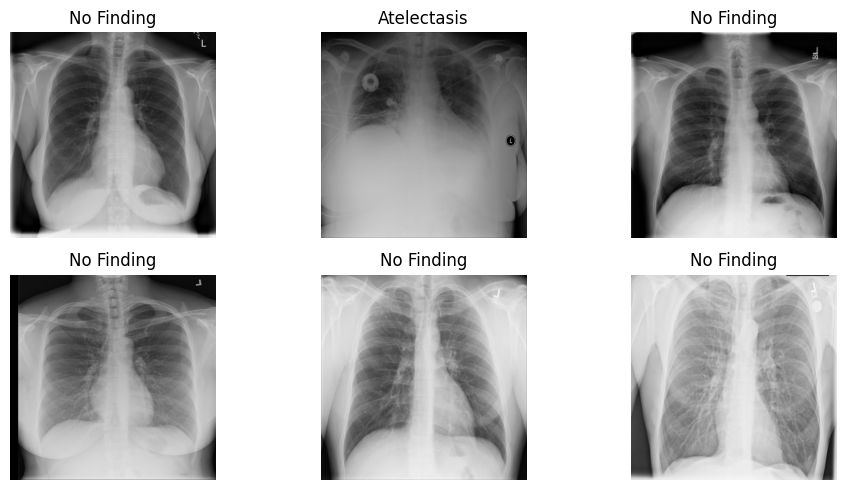

In [8]:
plt.figure(figsize=(10,5))

for i in range(1, 7):
    image_name= train_df.iloc[i,0]
    label_series= train_df.iloc[i,1:]
    label= label_series[label_series==1].index.tolist()[0]
    image_com_path= image_path+ image_name
    img= Image.open(image_com_path) # image mode=RGB size=384x384


    plt.subplot(2, 3, i)
    plt.imshow(img)
    plt.title(label)
    plt.axis("off")


plt.tight_layout()  # adjusts spacing
plt.show()

In [9]:
# Generator
class DataGenerator(Sequence):
    def __init__(self, df, image_path, batch_size=32):
        self.df=df
        self.image_path= image_path
        self.batch_size=batch_size 
    def __len__(self):
        return len(self.df)//self.batch_size

    def __getitem__(self, idx):
        batch= self.df.iloc[idx*self.batch_size:(idx+1)*self.batch_size, :]

        X, y= [], []
        for _, row in batch.iterrows():
            img= Image.open(self.image_path+row.iloc[0])
            img= img.resize((224, 224))
            img= np.array(img)/255.0
            
            X.append(img)
            y.append(row.iloc[1:].to_numpy(dtype='float32')) # .values does NOT guarantee numeric dtype

        return np.array(X), np.array(y)



# train_datagen= ImageDataGenerator(
#     rescale=1./255,
#     shear_range=0.2,
#     zoom_range=0.2,
#     horizontal_flip=True 
# )


# class DataAugmentGenerator(Sequence):
#     def __init__(self, df, image_path, batch_size=32):
#         self.df=df
#         self.image_path= image_path
#         self.batch_size=batch_size 

#     def __len__(self):
#         return len(self.df)//self.batch_size 

#     def __getitem__(self, idx):
#         batch= self.df.iloc[idx*self.batch_size:(idx+1)*self.batch_size,:]

#         images, labels=[], []
#         for _, row in batch.iterrows():
#             img= image.load_img(os.path.join(self.image_path, row.iloc[0]))
            
            
            
            

train_gen= DataGenerator(train_df, image_path=image_path, batch_size=94)

X_, y_= train_gen[0]



In [10]:
print(X_.dtype)
print(y_.dtype)

print(X_.shape)
print(y_.shape)

float64
float32
(94, 224, 224, 3)
(94, 20)


In [11]:
from tensorflow.keras.models import Sequential
from tensorflow import keras
from keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout, GlobalAveragePooling2D
from keras.optimizers import Adam


In [12]:
# model= Sequential()

# model.add(Conv2D(32, kernel_size=(3,3), padding="valid",activation='relu', input_shape=(224,224,3)))
# model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))
# # model.add(Conv2D(128, kernel_size=(3,3), padding='valid', activation='relu'))
# # model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

# model.add(Flatten())
# # model.add(Dense(128, activation='relu'))
# model.add(Dense(84, activation='relu'))
# model.add(Dense(20, activation='softmax'))

# model.summary()

In [13]:
# adam= Adam(learning_rate=0.01)

# model.compile(loss='categorical_crossentropy', optimizer=adam, metrics=['accuracy'])

# history= model.fit(train_gen, epochs=10)

In [14]:
# plt.plot(history.history['accuracy'], label='Train Accuracy')

# plt.xlabel("Epochs")
# plt.ylabel("Accuracy")

# plt.legend()
# plt.show()

In [15]:
# plt.plot(history.history['loss'], label='Train Loss')

# plt.xlabel("Epochs")
# plt.ylabel("Loss")

# plt.legend()
# plt.show()

In [16]:
test_df.shape

(17015, 1)

## Transfer Learning (Fine-Tuning):

In [17]:
counts= train_df.iloc[:,1:].sum().sort_values(ascending=False).values
class_names= np.array(train_df.iloc[:,1:].sum().sort_values(ascending=False).index).astype('str')

total= train_df.iloc[:,1:].sum().sum()

# pos_weight: how much to boost the positive (disease present) signal
# rare class → very few positives → needs very high weight
pos_weights= (total-counts)/counts # # negative/positive ratio per class

print("Positive weights per class:")
for name, w in zip(class_names, pos_weights):
    print(f"{name:<35} {w:.1f}x")

# option-1 ; weighted bce

def weighted_bce(pos_weights):
    pos_w= tf.constant(pos_weights, dtype=tf.float32)

    def loss(y_true, y_pred):
        # Clip predictions to avoid log(0) which gives infinity
        y_pred= tf.clip_by_value(y_pred, 1e-7, 1- 1e-7)

        # Standard BCE formula but with pos_weight multiplied on positive terms
        # When y_true=1 (disease present): loss is amplified by pos_weight
        # When y_true=0 (disease absent):  loss is normal
        bce = -(
            pos_w * y_true * tf.math.log(y_pred) +          # positive term
            (1 - y_true) * tf.math.log(1 - y_pred)          # negative term
        )
        return tf.reduce_mean(bce)

    return loss

bce_loss_fn= weighted_bce(pos_weights)


## Option 2 — Focal Loss (best for extreme imbalance)
# Focal loss solves a different problem:
# Easy examples (No Finding, very common) → model is already confident → low loss
# Hard examples (Pneumomediastinum, 5 samples) → model is uncertain → high loss
# gamma controls how much to down-weight easy examples
# alpha controls class balance (same as pos_weight above)

def focal_loss(pos_weights, gamma=2.0):
    pos_w= tf.constant(pos_weights, dtype=tf.float32)

    def loss(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)

        # p_t = probability of the TRUE class
        # if disease present (y_true=1): p_t = y_pred
        # if disease absent  (y_true=0): p_t = 1 - y_pred
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)

        # (1 - p_t)^gamma is the "focusing factor"
        # when model is confident (p_t close to 1): factor ≈ 0 → low loss
        # when model is uncertain (p_t close to 0): factor ≈ 1 → high loss
        focal_factor = tf.pow(1 - p_t, gamma)

        # Apply class balance weights on top
        alpha_t = y_true * pos_w + (1 - y_true) * 1.0

        bce = -(
            y_true * tf.math.log(y_pred) +
            (1 - y_true) * tf.math.log(1 - y_pred)
        )

        focal = alpha_t * focal_factor * bce
        return tf.reduce_mean(focal)

    return loss

focal_loss_fn = focal_loss(pos_weights, gamma=2.0)



# Option 3 — Asymmetric Loss (best match for YOUR competition metric)
"""
This is the most important one for our case. our competition penalises FN (missed disease) 5 times as much as FP (false alarm).
our loss function should reflect that exact same asymmetry:
"""

def asymmetric_loss(pos_weights, gamma_neg=4.0, gamma_pos=1.0):
    """
    Different focusing for positives vs negatives:
    
    gamma_pos=1 → mild focusing on hard positive examples (disease present)
    gamma_neg=4 → aggressive focusing on hard negative examples (no disease)
    
    This means:
    - Easy negatives (No Finding, model correctly says 0) -> almost ignored
    - Hard positives (rare disease, model misses it)      -> heavily penalised
    
    Perfectly matches our competition: FN costs 2x more than FP
    """
    pos_w = tf.constant(pos_weights, dtype=tf.float32)

    def loss(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)

        # ── Positive part (disease IS present, y_true=1) ──────────
        pos_loss = y_true * (
            pos_w *
            tf.pow(1 - y_pred, gamma_pos) *   # mild focusing
            tf.math.log(y_pred)
        )

        # ── Negative part (disease NOT present, y_true=0) ─────────
        # Shift prediction by margin to avoid penalising easy negatives
        y_pred_neg = tf.clip_by_value(y_pred, 1e-7, 0.999)
        neg_loss = (1 - y_true) * (
            tf.pow(y_pred_neg, gamma_neg) *   # aggressive focusing
            tf.math.log(1 - y_pred_neg)
        )

        loss_val = -tf.reduce_mean(pos_loss + neg_loss)
        return loss_val

    return loss

# gamma_neg > gamma_pos means we down-weight easy negatives MORE
# which forces the model to focus on rare positive cases
asymmetric_loss_fn = asymmetric_loss(pos_weights, gamma_neg=4.0, gamma_pos=1.0)


    

        
        
    

Positive weights per class:
No Finding                          0.5x
Infiltration                        8.8x
Atelectasis                         20.7x
Effusion                            22.7x
Nodule                              32.4x
Mass                                39.9x
Pneumothorax                        44.8x
Consolidation                       77.4x
Pleural_Thickening                  83.0x
Cardiomegaly                        84.1x
Fibrosis                            130.2x
Edema                               155.6x
Tortuous Aorta                      200.0x
Emphysema                           295.8x
Pneumonia                           318.0x
Calcification of the Aorta          559.9x
Pneumoperitoneum                    1159.1x
Hernia                              1378.5x
Subcutaneous Emphysema              2125.8x
Pneumomediastinum                   10207.6x


I0000 00:00:1774219398.193690      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774219398.200036      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


### gamma=0 → focal loss becomes plain BCE (no focusing at all)
### gamma=1 → mild focusing (good starting point)
### gamma=2 → standard focal loss (most common in papers)
### gamma=4 → aggressive (good for your extreme imbalance)
### gamma>5 → usually too aggressive, training becomes unstable

## For our dataset recommend starting with:
gamma_pos = 1.0   # mild on positives — don't over-penalise false negatives
gamma_neg = 4.0   # aggressive on negatives — ignore easy No Finding predictions

### After first training run, if model still misses rare classes → increase gamma_neg to 5
### If training becomes unstable (loss goes to NaN)            → decrease gamma_neg to 3

Multi-class:  one image → exactly ONE disease (mutually exclusive)
              e.g. cat OR dog OR bird

Multi-label:  one image → CAN HAVE multiple diseases simultaneously  
              e.g. Atelectasis=1, Effusion=1, Nodule=0, ...

Your data is multi-label because one X-ray can show Atelectasis AND Effusion AND Cardiomegaly at the same time. So multi_label=True is correct. At keras.metrics.AUC()

In [18]:
from tensorflow.keras.applications.vgg16 import VGG16

In [19]:
conv_base= VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224, 3)
)

conv_base.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
conv_base.trainable=True

set_trainable=False

for layer in conv_base.layers:
    if layer.name=="block5_conv1":
        set_trainable=True
    if set_trainable:
        layer.trainable=True
    else:
        layer.trainable=False
conv_base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 7,079,424 (27.01 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [21]:
model1= Sequential()

model1.add(conv_base)
model1.add(Flatten())


model1.add(Dense(128, activation='relu'))
model1.add(Dense(84, activation='relu'))
model1.add(Dense(20, activation='softmax'))

model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,836 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 20)             │         1,700 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,938,616 (68.43 MB)

 Trainable params: 10,303,352 (39.30 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [22]:
model1.compile(loss='categorical_crossentropy', optimizer= keras.optimizers.RMSprop(learning_rate=1e-5), metrics=['accuracy'])

# history2= model1.fit(train_gen, epochs=11)

In [23]:
# plt.plot(history2.history['accuracy'], label='Train Accuracy')

# plt.xlabel("Epochs")
# plt.ylabel("Accuracy")

# plt.legend()
# plt.show()

In [24]:
# plt.plot(history2.history['loss'], label='Train Loss')

# plt.xlabel("Epochs")
# plt.ylabel("Loss")

# plt.legend()
# plt.show()

In [25]:
from keras.applications import DenseNet121
from keras.optimizers import AdamW

In [26]:
conv_base_denseNet= DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224, 3)
    
)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [27]:
conv_base_denseNet.trainable=True

set_trainable=False

for layer in conv_base_denseNet.layers:
    if layer=="conv5_block15_2_conv":
        set_trainable=True

    if set_trainable:
        layer.trainable=True
    else:
        layer.trainable=False 

        

In [28]:
model2= Sequential()

model2.add(conv_base_denseNet)

model2.add(GlobalAveragePooling2D())
model2.add(Dense(512, activation='relu'))
model2.add(Dropout(0.2))
model2.add(Dense(128, activation='relu'))
model2.add(Dropout(0.2))
model2.add(Dense(20, activation='sigmoid'))

model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 20)             │         2,580 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,630,548 (29.11 MB)

 Trainable params: 593,044 (2.26 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [29]:
adamW= AdamW(learning_rate=1e-3, weight_decay=1e-4)

model2.compile(loss= asymmetric_loss_fn, optimizer=adamW, metrics=[keras.metrics.AUC(multi_label=True, name="auc")]) # AUC(AUC = Area Under the ROC Curve) -> Creates a metric that computes ROC-AUC during training/validation.;; 

history2= model2.fit(train_gen, epochs=12)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/12


I0000 00:00:1774219419.591615      75 service.cc:152] XLA service 0x7b9798002740 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774219419.591668      75 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1774219419.591675      75 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1774219423.328832      75 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1774219441.820968      75 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


543/543 ━━━━━━━━━━━━━━━━━━━━ 699s 1s/step - auc: 0.4883 - loss: 2.4944
Epoch 2/12
543/543 ━━━━━━━━━━━━━━━━━━━━ 472s 869ms/step - auc: 0.5085 - loss: 0.5204
Epoch 3/12
543/543 ━━━━━━━━━━━━━━━━━━━━ 469s 864ms/step - auc: 0.5519 - loss: 0.4784
Epoch 4/12
543/543 ━━━━━━━━━━━━━━━━━━━━ 479s 881ms/step - auc: 0.5874 - loss: 0.4481
Epoch 5/12
543/543 ━━━━━━━━━━━━━━━━━━━━ 482s 888ms/step - auc: 0.6051 - loss: 0.4433
Epoch 6/12
543/543 ━━━━━━━━━━━━━━━━━━━━ 475s 875ms/step - auc: 0.6201 - loss: 0.4337
Epoch 7/12
543/543 ━━━━━━━━━━━━━━━━━━━━ 475s 874ms/step - auc: 0.6131 - loss: 0.4337
Epoch 8/12
543/543 ━━━━━━━━━━━━━━━━━━━━ 488s 898ms/step - auc: 0.6468 - loss: 0.4192
Epoch 9/12
543/543 ━━━━━━━━━━━━━━━━━━━━ 479s 881ms/step - auc: 0.6499 - loss: 0.4180
Epoch 10/12
543/543 ━━━━━━━━━━━━━━━━━━━━ 471s 866ms/step - auc: 0.6498 - loss: 0.4141
Epoch 11/12
543/543 ━━━━━━━━━━━━━━━━━━━━ 474s 873ms/step - auc: 0.6446 - loss: 0.4264
Epoch 12/12
543/543 ━━━━━━━━━━━━━━━━━━━━ 489s 900ms/step - auc: 0.6550 - loss

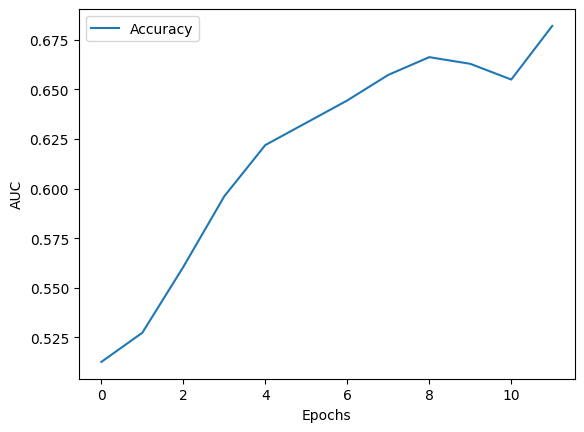

In [30]:
plt.plot(history2.history['auc'], label='Accuracy')

plt.xlabel("Epochs")
plt.ylabel("AUC")

plt.legend()
plt.show()

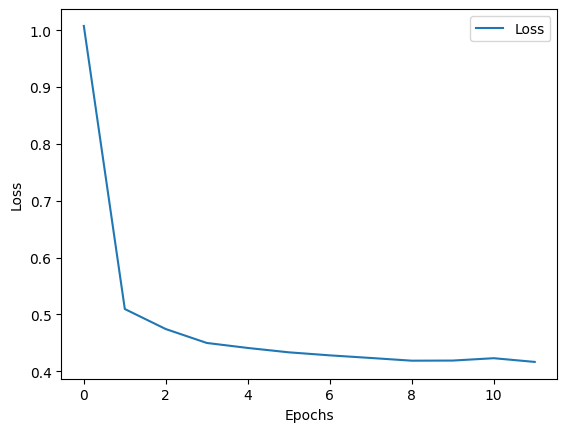

In [31]:
plt.plot(history2.history['loss'], label='Loss')

plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()
plt.show()

In [32]:
## Evaluation

import numpy as np
from sklearn.metrics import confusion_matrix

def asymmetric_cost_score(y_true, y_pred, class_names=None, verbose=True):
    """
    Macro-averaged asymmetric cost function for multi-label/multi-class chest x-ray
    score(c)= (TP_c - FP_c -5FN_c)/N_c

    final= mean of score(c) across all C lcasses

    args:
    y_true : np.ndarray of shape (n_samples, n_classes) — ground truth binary labels
    y_pred : np.ndarray of shape (n_samples, n_classes) — predicted binary labels
    class_names: list of str, optional
    verbose: bool - print pre-class breakdown

    return:
    final_score: float (eg -4.xx or -5.xx)
    per_class : dict {class_name: score}
    """

    y_true= np.array(y_true)
    y_pred= np.array(y_pred)

    assert y_true.shape==y_pred.shape , "Shape mismatch between y_true and y_pred"

    n_classes= y_true.shape[1]

    if class_names is None:
        class_names= [f"Class_{i}" for i in range(n_classes)]

    per_class_scores={}

    for c in range(n_classes):
        name= class_names[c]

        gt= y_true[:, c]
        pred= y_pred[:,c]

        TP= np.sum((gt==1) & (pred==1))
        FP= np.sum((gt==0) & (pred==1))
        FN= np.sum((gt==1) & (pred==0))
        N= np.sum(gt==1) # total number of positives in ground truth

        if N==0:
            # No ground truth samples for this class → score = 0
            score=0
            if verbose:
                print(f"  {name:<35} | N=0, score=0.0 (skipped)")

        else:
            score= (TP-FP -5* FN)/N
            if verbose:
                print(f"  {name} | N={N:d} | TP= {TP:d} FP={FP:d} FN={FN:d} | score= {score: .4f}")

        per_class_scores[name]=score

    final_score = np.mean(list(per_class_scores.values()))

    if verbose:
        print(f"\n  {'Final macro-averaged score':<35}   {final_score:+.6f}")
    return final_score, per_class_scores

In [33]:
y_train_pred= model2.predict(train_gen)

543/543 ━━━━━━━━━━━━━━━━━━━━ 489s 880ms/step


In [34]:
y_train_like_zero_matrix= np.zeros_like(y_train_pred)

y_train_args_max= np.argmax(y_train_pred, axis=1)

y_train_like_zero_matrix[np.arange(len(y_train_pred)),y_train_args_max]=1

y_train_like_zero_matrix.shape

(51042, 20)

In [35]:
final_score, per_class_scores=  asymmetric_cost_score(train_df.iloc[:-1,1:],y_train_like_zero_matrix)

  Class_0 | N=2351 | TP= 0 FP=0 FN=2351 | score= -5.0000
  Class_1 | N=600 | TP= 0 FP=0 FN=600 | score= -5.0000
  Class_2 | N=651 | TP= 0 FP=0 FN=651 | score= -5.0000
  Class_3 | N=326 | TP= 0 FP=0 FN=326 | score= -5.0000
  Class_4 | N=2156 | TP= 0 FP=0 FN=2156 | score= -5.0000
  Class_5 | N=172 | TP= 0 FP=0 FN=172 | score= -5.0000
  Class_6 | N=389 | TP= 0 FP=0 FN=389 | score= -5.0000
  Class_7 | N=37 | TP= 0 FP=0 FN=37 | score= -5.0000
  Class_8 | N=5206 | TP= 0 FP=0 FN=5206 | score= -5.0000
  Class_9 | N=1249 | TP= 0 FP=0 FN=1249 | score= -5.0000
  Class_10 | N=1527 | TP= 0 FP=0 FN=1527 | score= -5.0000
  Class_11 | N=608 | TP= 0 FP=0 FN=608 | score= -5.0000
  Class_12 | N=160 | TP= 0 FP=0 FN=160 | score= -5.0000
  Class_13 | N=1114 | TP= 0 FP=0 FN=1114 | score= -5.0000
  Class_14 | N=44 | TP= 0 FP=0 FN=44 | score= -5.0000
  Class_15 | N=5 | TP= 0 FP=0 FN=5 | score= -5.0000
  Class_16 | N=24 | TP= 0 FP=0 FN=24 | score= -5.0000
  Class_17 | N=254 | TP= 0 FP=0 FN=254 | score= -5.0000


In [36]:
class TestGenerator(Sequence):
    def __init__(self,df, image_path, batch_size=32 ):
        self.df= df
        self.image_path= image_path
        self.batch_size=batch_size

    def __len__(self):
        return len(self.df)//self.batch_size

    def __getitem__(self, idx):
        batch= self.df.iloc[idx*self.batch_size:(idx+1)*self.batch_size, :]
        X=[]
        for _, row in batch.iterrows():
            img= Image.open(self.image_path+ row.iloc[0])
            img= img.resize((224,224))
            img= np.array(img)/255.

            X.append(img)
        return np.array(X)


test_gen= TestGenerator(test_df, image_path, batch_size=83)


y_pred= model2.predict(test_gen)

205/205 ━━━━━━━━━━━━━━━━━━━━ 265s 1s/step


In [37]:
y_row_max_idx= np.argmax(y_pred, axis=1)

y_pred_zero_matrix= np.zeros_like(y_pred)
y_pred_zero_matrix[np.arange(len(y_pred)), y_row_max_idx]=1

In [38]:
y_pred.shape

(17015, 20)

In [39]:
test_submission_df_part= pd.DataFrame(y_pred_zero_matrix.astype(int), columns= np.array(train_df.columns[1:]).astype("str"))
test_submission_df_part.insert(0, "id", test_df.iloc[:,0])

In [40]:
test_submission_df_part.to_csv("submission.csv", index=False)